# Broadband Continuous Signal Processing with STFT-Based Propagation

This notebook demonstrates the BroadbandPassiveSonarArraySimulator which uses frequency-domain propagation for continuous broadband signals. It showcases:

- Continuous phase-coherent signal generation
- STFT-based frequency-domain propagation
- Time-varying transfer functions (moving platform)
- Overlap-add signal reconstruction

## Underwater Acoustics Background

In passive sonar, acoustic signals from underwater targets are received by sensor arrays. This notebook simulates:

1. **Source Signal Generation**: Realistic ship signatures with broadband tonals (propeller, machinery) and colored noise (cavitation, turbulence)
2. **Acoustic Propagation**: Frequency-domain ray tracing using RTRS (Range-dependent Two-dimensional Ray Simulation)
3. **Array Reception**: Multi-sensor time-series signals with proper phase relationships

**Key Concept - FFT Scaling**: When converting time-domain signals to frequency domain, the FFT introduces a scaling factor of N/2 (for single-sided spectrum). To get proper amplitude in µPa, we multiply by `2.0/N`. Similarly, spectrograms return Power Spectral Density (PSD) in µPa²/Hz, which must be properly referenced to 1 µPa for underwater acoustics.



## 1. Import Libraries and Set Random Seed

In [50]:
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(1999)

from datetime import datetime, timedelta
from scipy.signal import spectrogram
from scipy.io import wavfile
from stonesoup.models.transition.linear import (
    CombinedLinearGaussianTransitionModel,
    ConstantVelocity,
)
from stonesoup.types.groundtruth import GroundTruthState, GroundTruthPath

from nereus.platform import TowedArrayPlatform
from nereus.models.environment import Linear, FlatBathymetry
from nereus.models.propagation import rtrsAcousticPropagationModel
from nereus.signal.anthropogenic import BroadbandTonalSignal, BroadbandShipSignal
from nereus.simulator import BroadbandPassiveSonarArraySimulator

print("All libraries imported successfully")

All libraries imported successfully


## 2. Define Simulation Parameters

Configure the simulation timing: 60 seconds total duration with 2-second timesteps (30 steps).

In [51]:
# Simulation parameters
SIM_RATE = 2.0
SIM_PARAMS = {
    "start_time": datetime.now().replace(hour=0, minute=0, second=0, microsecond=0),
    "time_interval": timedelta(seconds=SIM_RATE),
    "num_steps": 30,
}

total_duration_s = SIM_PARAMS["num_steps"] * SIM_PARAMS["time_interval"].total_seconds()

print(f"=== Broadband Continuous Signal Processing Demo ===")
print(f"Total simulation duration: {total_duration_s} s")
print(f"Number of timesteps: {SIM_PARAMS['num_steps']}")
print(f"Timestep interval: {SIM_PARAMS['time_interval'].total_seconds()} s")

=== Broadband Continuous Signal Processing Demo ===
Total simulation duration: 60.0 s
Number of timesteps: 30
Timestep interval: 2.0 s


## 3. Define Ship/Platform and Array Parameters

The ship platform remains stationary while the towed array (100 sensors, 200m cable, 1m spacing) is deployed at 200m depth.

In [52]:
SHIP_PARAMS = {
    "start_vector": np.array([0, 0, 0, 0, -10.0, 0]),  # Stationary ship
    "position_mapping": [0, 2, 4],
    "velocity_mapping": [1, 3, 5],
    "transition_model": CombinedLinearGaussianTransitionModel(
        [ConstantVelocity(0), ConstantVelocity(0), ConstantVelocity(0)]
    ),
}

ARRAY_PARAMS = {
    "num_sensors": 100,
    "tow_cable_length": 200.0,
    "sensor_spacing": 1.0,
    "array_depth": -200.0,
}

print(f"Platform: Stationary ship at surface")
print(f"Array: {ARRAY_PARAMS['num_sensors']} sensors, "
      f"{ARRAY_PARAMS['tow_cable_length']}m cable, "
      f"{ARRAY_PARAMS['sensor_spacing']}m spacing")
print(f"Array depth: {ARRAY_PARAMS['array_depth']} m")

Platform: Stationary ship at surface
Array: 100 sensors, 200.0m cable, 1.0m spacing
Array depth: -200.0 m


## 4. Define Target Parameters

The target starts at 4.5 km range with slow motion. Its acoustic signature consists of 4 tonal components at different frequencies (60, 85, 120, 200 Hz) with amplitudes ranging from 75-100 dB re 1 µPa.

In [53]:
TARGET_PARAMS = {
    "start_vector": np.array([0, 0, 4500, -10, -10.0, 0]),  # Moving target
    "position_mapping": [0, 2, 4],
    "velocity_mapping": [1, 3, 5],
    "transition_model": CombinedLinearGaussianTransitionModel(
        [ConstantVelocity(0.001), ConstantVelocity(0.001), ConstantVelocity(0)]
    ),
    "amplitudes_upa": 10 ** (np.array([80.0, 95.0, 100.0, 75.0]) / 20), 
    "frequencies_hz": np.array([60.0, 85.0, 120.0, 200.0]),
    "phases_rad": np.random.uniform(0, 2 * np.pi, 4),
    "tonal_bandwidth_hz": 2.0,
    "noise_amplitude_upa":10 ** (60 / 20),
    "noise_spectral_exponent":-1.0,
}

# Convert amplitudes to dB for display
amplitudes_db = 20 * np.log10(TARGET_PARAMS["amplitudes_upa"])

print(f"Target initial position: {TARGET_PARAMS['start_vector'][2]:.0f} m range")
print(f"Target depth: {TARGET_PARAMS['start_vector'][4]:.0f} m")
print(f"Tonal frequencies: {TARGET_PARAMS['frequencies_hz']} Hz")
print(f"Tonal amplitudes: {amplitudes_db} dB re 1 µPa")

Target initial position: 4500 m range
Target depth: -10 m
Tonal frequencies: [ 60.  85. 120. 200.] Hz
Tonal amplitudes: [ 80.  95. 100.  75.] dB re 1 µPa


## 5. Define Broadband Signal and Propagation Parameters

**Signal Parameters**: STFT processing with 500-sample frames (1 second at 500 Hz sampling rate) and 75% overlap (hop_factor=4).

**Propagation Parameters**: Constant sound speed profile and flat bathymetry at 100m depth.

In [54]:
SIGNAL_PARAMS = {
    "duration_s": total_duration_s,  # Long continuous signal
    "sampling_rate_hz": 500.0,
    "frame_len": 500,  # STFT frame length
    "hop_factor": 2,  # 75% overlap
    "fade_in_ms": 1000.0,  # Gentle fade-in
}

PROP_PARAMS = {
    # "ssp": Constant(speed=1500.0), 
    "ssp": Linear(surface_speed=1500.0, gradient=0.2),
    # "ssp": Munk(),
    "attenuation_factor": 0.5, 
    "bathymetry": FlatBathymetry(depth=-150.0),
    # "bathymetry": FlatBathymetry(depth=-5000.0),
    "step_m": 20.0,
    "azimuth_search_width": 2.0,
    "azimuth_resolution": 0.5,
    "elevation_range": (-25.0, 25.0),
    "elevation_resolution": 1.0,
}

# Sensor to analyze
SENSOR_TO_ANALYZE = ARRAY_PARAMS["num_sensors"] // 2

print(f"Signal sampling rate: {SIGNAL_PARAMS['sampling_rate_hz']} Hz")
print(f"STFT frame length: {SIGNAL_PARAMS['frame_len']} samples")
print(f"STFT hop factor: {SIGNAL_PARAMS['hop_factor']} (75% overlap)")
print(f"Bathymetry: Flat at {PROP_PARAMS['bathymetry'].depth} m depth")
print(f"Analyzing sensor: {SENSOR_TO_ANALYZE}")

Signal sampling rate: 500.0 Hz
STFT frame length: 500 samples
STFT hop factor: 2 (75% overlap)
Bathymetry: Flat at -150.0 m depth
Analyzing sensor: 50


## 6. Create Platform with Towed Array

Initialize the towed array platform and simulate motion through timesteps.

In [55]:
print("Creating platform with vertical motion...")
initial_state = GroundTruthState(
    SHIP_PARAMS["start_vector"], timestamp=SIM_PARAMS["start_time"]
)

platform = TowedArrayPlatform(
    states=[initial_state],
    position_mapping=SHIP_PARAMS["position_mapping"],
    velocity_mapping=SHIP_PARAMS["velocity_mapping"],
    transition_models=[SHIP_PARAMS["transition_model"]],
    transition_times=[timedelta(seconds=total_duration_s)],
    num_sensors=ARRAY_PARAMS["num_sensors"],
    cable_length_m=ARRAY_PARAMS["tow_cable_length"],
    sensor_spacing_m=ARRAY_PARAMS["sensor_spacing"],
    array_depth_m=ARRAY_PARAMS["array_depth"],
)

# Add vertical motion to platform
depth_change_per_step = -10.0  # Move up 10m per timestep
for i in range(1, SIM_PARAMS["num_steps"]):
    new_time = SIM_PARAMS["start_time"] + i * SIM_PARAMS["time_interval"]
    platform.move(new_time)

# Get final array depth
final_platform_state = platform.get_platform_state_at(
    SIM_PARAMS["start_time"] + (SIM_PARAMS["num_steps"] - 1) * SIM_PARAMS["time_interval"]
)
final_depth = final_platform_state.array.state_vector[2, 0] if final_platform_state else ARRAY_PARAMS["array_depth"]

print(f"Platform created")
print(f"  Array depth: {ARRAY_PARAMS['array_depth']} m -> {final_depth:.1f} m")

Creating platform with vertical motion...
Platform created
  Array depth: -200.0 m -> -200.0 m


## 7. Create Target Trajectory

Generate the target ground truth path with acoustic metadata.

In [56]:
print("Creating target trajectory...")
target_states = [
    GroundTruthState(
        TARGET_PARAMS["start_vector"],
        timestamp=SIM_PARAMS["start_time"],
        metadata={
            "amplitudes_upa": TARGET_PARAMS["amplitudes_upa"],
            "frequencies_hz": TARGET_PARAMS["frequencies_hz"],
            "phases_rad": TARGET_PARAMS["phases_rad"],
            "position_mapping": TARGET_PARAMS["position_mapping"],
            "velocity_mapping": TARGET_PARAMS["velocity_mapping"],
        },
    )
]

transition_model = TARGET_PARAMS["transition_model"]
for i in range(1, SIM_PARAMS["num_steps"]):
    new_time = SIM_PARAMS["start_time"] + i * SIM_PARAMS["time_interval"]
    time_interval = new_time - target_states[-1].timestamp
    new_state_vector = transition_model.function(
        target_states[-1], noise=False, time_interval=time_interval
    )
    new_state = GroundTruthState(
        new_state_vector,
        timestamp=new_time,
        metadata=target_states[-1].metadata,
    )
    target_states.append(new_state)

target_ground_truth = GroundTruthPath(target_states)
print(f"Target trajectory created: {len(target_states)} states")

Creating target trajectory...
Target trajectory created: 30 states


## 8. Create Broadband Signal Model

Use **BroadbandShipSignal** for realistic ship acoustics: broadband tonals (1 Hz bandwidth to simulate mechanical resonances) plus colored noise (85 dB re 1 µPa, pink noise spectrum with 1/f decay).

In [57]:
print("Creating broadband signal model...")

signal_model = BroadbandShipSignal(
    duration_s=SIGNAL_PARAMS["duration_s"],
    sampling_rate_hz=SIGNAL_PARAMS["sampling_rate_hz"],
    frame_len=SIGNAL_PARAMS["frame_len"],
    hop_factor=SIGNAL_PARAMS["hop_factor"],
    tonal_bandwidth_hz=1.0,  # Broader tonals (simulates mechanical resonances)
    noise_amplitude_upa=10 ** (85 / 20),  # 85 dB re 1 µPa background noise
    noise_spectral_exponent=-1.0,  # Pink noise (1/f)
    noise_freq_range_hz=(0.0, SIGNAL_PARAMS["sampling_rate_hz"]),
)

print(f"BroadbandShipSignal model created")
print(f"  Tonal bandwidth: 1.0 Hz")
print(f"  Noise level: 85 dB re 1 µPa (pink noise)")

Creating broadband signal model...
BroadbandShipSignal model created
  Tonal bandwidth: 1.0 Hz
  Noise level: 85 dB re 1 µPa (pink noise)


## 9. Create Propagation Model and Simulator

Set up the **rtrs** (Range-dependent Two-dimensional Ray Simulation) acoustic propagation model and initialize the broadband passive sonar simulator.

In [60]:
prop_model = rtrsAcousticPropagationModel(
    ssp=PROP_PARAMS["ssp"],
    bathymetry=PROP_PARAMS["bathymetry"],
    step_m=PROP_PARAMS["step_m"],
    azimuth_search_width=PROP_PARAMS["azimuth_search_width"],
    azimuth_resolution=PROP_PARAMS["azimuth_resolution"],
    elevation_range=PROP_PARAMS["elevation_range"],
    elevation_resolution=PROP_PARAMS["elevation_resolution"],
)

signal_model = BroadbandShipSignal(
    duration_s=SIGNAL_PARAMS["duration_s"],
    sampling_rate_hz=SIGNAL_PARAMS["sampling_rate_hz"],
    frame_len=SIGNAL_PARAMS["frame_len"],
    hop_factor=SIGNAL_PARAMS["hop_factor"],
    tonal_bandwidth_hz=TARGET_PARAMS["tonal_bandwidth_hz"],
    noise_amplitude_upa=TARGET_PARAMS["noise_amplitude_upa"],
    noise_spectral_exponent=TARGET_PARAMS["noise_spectral_exponent"],
    noise_freq_range_hz=(0.0, SIGNAL_PARAMS["sampling_rate_hz"]/2),
    tonal_noise_is_constant=True,
    noise_is_constant=True,
)

simulator = BroadbandPassiveSonarArraySimulator(
    platform=platform,
    propagation_model=prop_model,
    signal_models=[signal_model],
    noise_model=None,
    beamformer=None,
    steering_calculator=None,
    ground_truth_paths=[target_ground_truth],
    fade_in_ms=SIGNAL_PARAMS["fade_in_ms"],
)

## 10. Run Simulation and Collect Sensor Data

Execute the simulation loop to generate sensor data at each timestep. The simulator processes signals in the frequency domain using STFT, applies propagation transfer functions, and reconstructs time-domain signals via overlap-add.

**Note**: This step may take several minutes depending on system performance.

In [61]:
print("Running broadband simulation...")
print()

all_sensor_signals = []
timestamps = []

for timestamp, sensor_data_set in simulator.sensor_data_gen():
    print(f"Processed timestep: {timestamp}")
    sensor_data = next(iter(sensor_data_set))
    all_sensor_signals.append(sensor_data.raw_signals)
    timestamps.append(timestamp)

# Concatenate all timestep signals
all_sensor_signals_array = np.concatenate(all_sensor_signals, axis=1)
continuous_signal = all_sensor_signals_array[SENSOR_TO_ANALYZE, :]
continuous_signal_first = all_sensor_signals_array[0, :]
continuous_signal_last = all_sensor_signals_array[-1, :]
time_axis = np.arange(continuous_signal.shape[0]) / SIGNAL_PARAMS["sampling_rate_hz"]

print()
print(f"Simulation complete!")
print(f"  Total signal length: {len(continuous_signal)} samples")
print(f"  Signal duration: {len(continuous_signal) / SIGNAL_PARAMS['sampling_rate_hz']:.1f} s")

Running broadband simulation...

Processed timestep: 2026-02-16 00:00:00
Processed timestep: 2026-02-16 00:00:02
Processed timestep: 2026-02-16 00:00:04
Processed timestep: 2026-02-16 00:00:06
Processed timestep: 2026-02-16 00:00:08
Processed timestep: 2026-02-16 00:00:10
Processed timestep: 2026-02-16 00:00:12
Processed timestep: 2026-02-16 00:00:14
Processed timestep: 2026-02-16 00:00:16
Processed timestep: 2026-02-16 00:00:18
Processed timestep: 2026-02-16 00:00:20
Processed timestep: 2026-02-16 00:00:22
Processed timestep: 2026-02-16 00:00:24
Processed timestep: 2026-02-16 00:00:26
Processed timestep: 2026-02-16 00:00:28
Processed timestep: 2026-02-16 00:00:30
Processed timestep: 2026-02-16 00:00:32
Processed timestep: 2026-02-16 00:00:34
Processed timestep: 2026-02-16 00:00:36
Processed timestep: 2026-02-16 00:00:38
Processed timestep: 2026-02-16 00:00:40
Processed timestep: 2026-02-16 00:00:42
Processed timestep: 2026-02-16 00:00:44
Processed timestep: 2026-02-16 00:00:46
Process

## 11. Retrieve Source Signal and Save WAV Files

Extract the source signal from the signal model cache and save both source and received signals as WAV files for audio playback.

In [62]:
print("Retrieving source signal from cache...")
try:
    source_signal = signal_model.get_source_signal()
except RuntimeError:
    print("Computing STFT to generate source signal...")
    signal_model.compute_stft(target_states[0])
    source_signal = signal_model.get_source_signal()

print(f"Source signal length: {len(source_signal)} samples")

# Save WAV files
print("\nSaving WAV files...")

def save_as_wav(signal, filename, sampling_rate):
    """Save complex or real signal as WAV file (normalized to int16)."""
    if np.iscomplexobj(signal):
        signal_real = np.real(signal)
    else:
        signal_real = signal
    
    max_val = np.max(np.abs(signal_real))
    if max_val > 0:
        signal_normalized = signal_real / max_val
    else:
        signal_normalized = signal_real
    
    signal_int16 = np.int16(signal_normalized * 32767)
    wavfile.write(filename, int(sampling_rate), signal_int16)
    print(f"  Saved: {filename}")

save_as_wav(source_signal, "wavs/source_signal_broadband.wav", 
            SIGNAL_PARAMS["sampling_rate_hz"])
save_as_wav(continuous_signal, "wavs/received_signal_broadband.wav", 
            SIGNAL_PARAMS["sampling_rate_hz"])

Retrieving source signal from cache...
Source signal length: 30000 samples

Saving WAV files...
  Saved: wavs/source_signal_broadband.wav
  Saved: wavs/received_signal_broadband.wav


## 12. Visualize Time-Domain Signal and Spectrogram

Plot the continuous time-domain signal and its spectrogram. Red dashed lines mark timestep boundaries where the propagation transfer function is updated.

**Important**: The spectrogram uses proper PSD scaling (dB re 1 µPa²/Hz) for underwater acoustics.

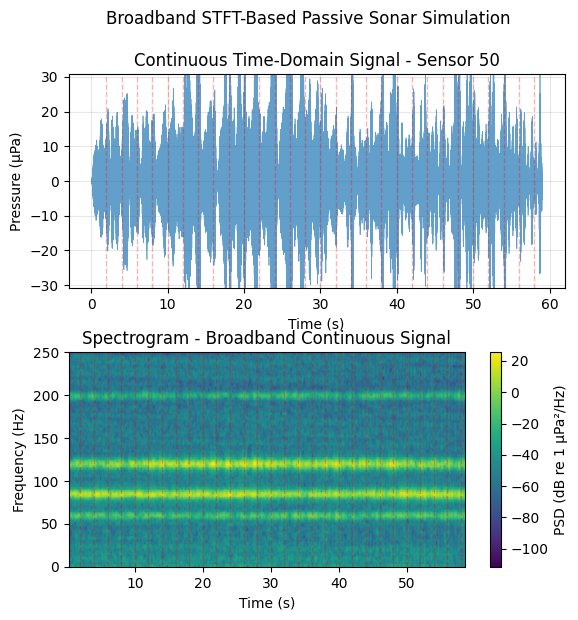

In [63]:
fig = plt.figure(figsize=(6.4, 6.4))
gs = fig.add_gridspec(2, 1, hspace=0.3, wspace=0.3)

# Plot 1: Time-domain signal
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(time_axis, np.real(continuous_signal), linewidth=0.5, alpha=0.7)
ax1.set_ylim(np.percentile(np.real(continuous_signal), 1), 
             np.percentile(np.real(continuous_signal), 99))
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Pressure (µPa)")
ax1.set_title(f"Continuous Time-Domain Signal - Sensor {SENSOR_TO_ANALYZE}")
ax1.grid(True, alpha=0.3)

# Add timestep boundaries
for i in range(1, SIM_PARAMS["num_steps"]):
    t_boundary = i * SIM_PARAMS["time_interval"].total_seconds()
    ax1.axvline(t_boundary, color="red", linestyle="--", alpha=0.3, linewidth=1)

# Plot 2: Spectrogram
ax2 = fig.add_subplot(gs[1, :])
signal_for_spec = np.real(continuous_signal)
f, t, Sxx = spectrogram(signal_for_spec, fs=SIGNAL_PARAMS["sampling_rate_hz"],
                        nperseg=256, noverlap=192, window="hann", scaling='density')
Sxx_db = 10 * np.log10(Sxx + 1e-20)  # Convert to dB re 1 µPa²/Hz
im = ax2.pcolormesh(t, f, Sxx_db, shading="gouraud", cmap="viridis")
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Frequency (Hz)")
ax2.set_title("Spectrogram - Broadband Continuous Signal")
plt.colorbar(im, ax=ax2, label="PSD (dB re 1 µPa²/Hz)")

# Add timestep boundaries
for i in range(1, SIM_PARAMS["num_steps"]):
    t_boundary = i * SIM_PARAMS["time_interval"].total_seconds()
    ax2.axvline(t_boundary, color="red", linestyle="--", alpha=0.3, linewidth=1)

plt.suptitle("Broadband STFT-Based Passive Sonar Simulation")
plt.show()

## 13. Visualize Target and Platform Trajectories

Show the trajectories in 2D Cartesian space (top view).

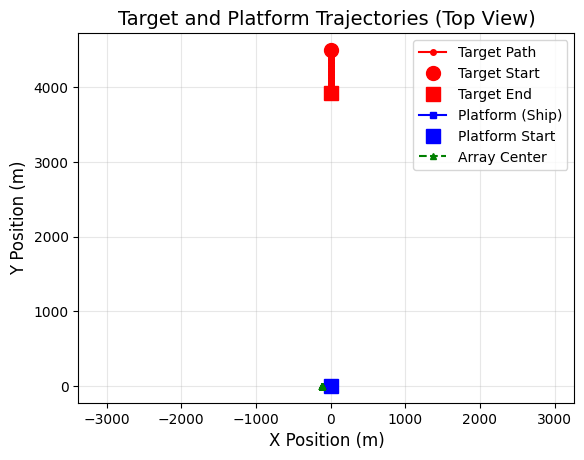

In [64]:
fig2, ax_path = plt.subplots()

# Extract positions
target_x = [state.state_vector[0] for state in target_ground_truth]
target_y = [state.state_vector[2] for state in target_ground_truth]

platform_x = []
platform_y = []
array_x = []
array_y = []

timesteps = [SIM_PARAMS["start_time"] + i * SIM_PARAMS["time_interval"]
             for i in range(SIM_PARAMS["num_steps"])]

for timestamp in timesteps:
    platform_state = platform.get_platform_state_at(timestamp)
    platform_x.append(platform_state.host.state.state_vector[0])
    platform_y.append(platform_state.host.state.state_vector[2])
    
    array_center = np.mean(platform_state.array.state_vector, axis=1)
    array_x.append(array_center[0])
    array_y.append(array_center[1])

# Plot trajectories
ax_path.plot(target_x, target_y, 'r-', label='Target Path', marker='o', markersize=4)
ax_path.plot(target_x[0], target_y[0], 'ro', markersize=10, label='Target Start')
ax_path.plot(target_x[-1], target_y[-1], 'rs', markersize=10, label='Target End')
ax_path.plot(platform_x, platform_y, 'b-', label='Platform (Ship)', marker='s', markersize=4)
ax_path.plot(platform_x[0], platform_y[0], 'bs', markersize=10, label='Platform Start')
ax_path.plot(array_x, array_y, 'g--', label='Array Center', marker='^', markersize=4)

ax_path.set_xlabel('X Position (m)', fontsize=12)
ax_path.set_ylabel('Y Position (m)', fontsize=12)
ax_path.set_title('Target and Platform Trajectories (Top View)', fontsize=14)
ax_path.legend(loc='best', fontsize=10)
ax_path.grid(True, alpha=0.3)
ax_path.axis('equal')
plt.show()

## 14. Compare First and Last Sensor Signals

Visualize spatial variation: signals from opposite ends of the 100-sensor array show time delays and amplitude differences due to array geometry.

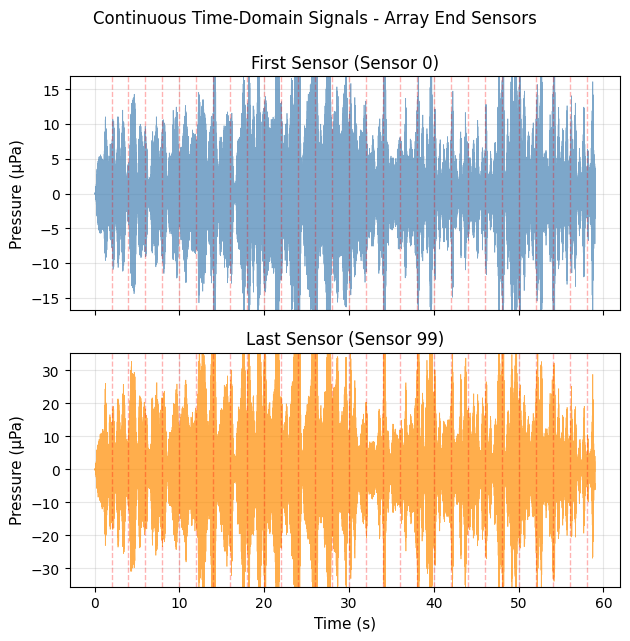

In [65]:
fig3, (ax_first, ax_last) = plt.subplots(2, 1, figsize=(6.4, 6.4), sharex=True)

# First sensor
ax_first.plot(time_axis, np.real(continuous_signal_first), linewidth=0.5, 
              alpha=0.7, color='steelblue')
ax_first.set_ylim(np.percentile(np.real(continuous_signal_first), 1),
                  np.percentile(np.real(continuous_signal_first), 99))
ax_first.set_ylabel("Pressure (µPa)", fontsize=11)
ax_first.set_title("First Sensor (Sensor 0)")
ax_first.grid(True, alpha=0.3)

for i in range(1, SIM_PARAMS["num_steps"]):
    t_boundary = i * SIM_PARAMS["time_interval"].total_seconds()
    ax_first.axvline(t_boundary, color="red", linestyle="--", alpha=0.3, linewidth=1)

# Last sensor
ax_last.plot(time_axis, np.real(continuous_signal_last), linewidth=0.5, 
             alpha=0.7, color='darkorange')
ax_last.set_ylim(np.percentile(np.real(continuous_signal_last), 1),
                 np.percentile(np.real(continuous_signal_last), 99))
ax_last.set_xlabel("Time (s)", fontsize=11)
ax_last.set_ylabel("Pressure (µPa)", fontsize=11)
ax_last.set_title(f"Last Sensor (Sensor {ARRAY_PARAMS['num_sensors'] - 1})")
ax_last.grid(True, alpha=0.3)

for i in range(1, SIM_PARAMS["num_steps"]):
    t_boundary = i * SIM_PARAMS["time_interval"].total_seconds()
    ax_last.axvline(t_boundary, color="red", linestyle="--", alpha=0.3, linewidth=1)

plt.suptitle("Continuous Time-Domain Signals - Array End Sensors", y=0.995)
plt.tight_layout()
plt.show()

## 15. Analyze Source Signal

Examine the source signal before propagation:
- **Time domain**: Shows the temporal structure
- **Spectrogram**: Reveals frequency content evolution over time
- **Frequency spectrum**: Shows tonal peaks with proper amplitude scaling

**Critical FFT Scaling**: We multiply by `2.0/N` to convert FFT magnitude to single-sided amplitude spectrum in µPa.

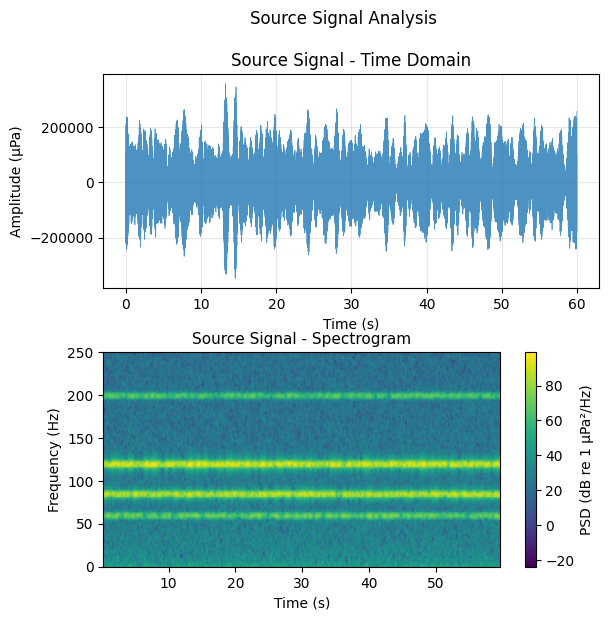

In [66]:
fig4 = plt.figure(figsize=(6.4, 6.4))
gs4 = fig4.add_gridspec(2, 1, hspace=0.3, wspace=0.3)

source_time_axis = np.arange(len(source_signal)) / SIGNAL_PARAMS["sampling_rate_hz"]

# Top: Source time domain
ax_src_time = fig4.add_subplot(gs4[0, :])
ax_src_time.plot(source_time_axis, np.real(source_signal), linewidth=0.5, alpha=0.8)
ax_src_time.set_xlabel('Time (s)', fontsize=10)
ax_src_time.set_ylabel('Amplitude (µPa)', fontsize=10)
ax_src_time.set_title('Source Signal - Time Domain')
ax_src_time.grid(True, alpha=0.3)

# Bottom: Source spectrogram
ax_src_spec = fig4.add_subplot(gs4[1, 0])
signal_for_spec_src = np.real(source_signal)
f_src, t_src, Sxx_src = spectrogram(signal_for_spec_src, 
                                     fs=SIGNAL_PARAMS["sampling_rate_hz"],
                                     nperseg=256, noverlap=192, window="hann",
                                     scaling='density')
Sxx_src_db = 10 * np.log10(Sxx_src + 1e-20)  # dB re 1 µPa²/Hz
im_src = ax_src_spec.pcolormesh(t_src, f_src, Sxx_src_db, shading="gouraud", 
                                 cmap="viridis")
ax_src_spec.set_xlabel('Time (s)', fontsize=10)
ax_src_spec.set_ylabel('Frequency (Hz)', fontsize=10)
ax_src_spec.set_title('Source Signal - Spectrogram', fontsize=11)
plt.colorbar(im_src, ax=ax_src_spec, label="PSD (dB re 1 µPa²/Hz)")

plt.suptitle("Source Signal Analysis")
plt.show()

## 16. Source Frequency Spectrum with Correct FFT Scaling

Plot the frequency spectrum of the source signal with **proper amplitude scaling**:
- FFT magnitude is multiplied by `2.0/N` to get single-sided amplitude
- Converted to dB re 1 µPa: `20 * log10(amplitude)`
- Red dashed lines mark target frequencies (60, 85, 120, 200 Hz)

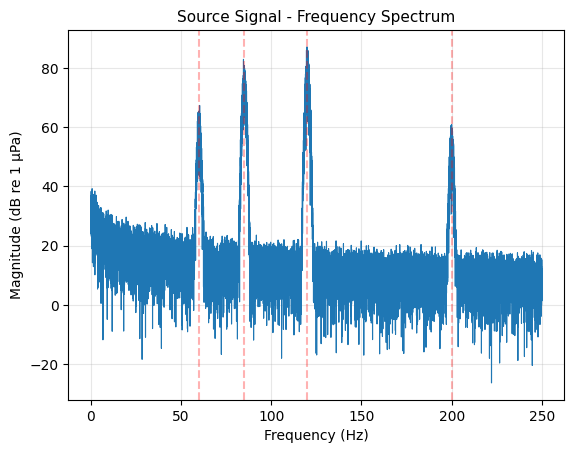

In [67]:
fig_src_freq, ax_src_freq = plt.subplots(1, 1, figsize=(6.4, 4.8))
signal_real_src = np.real(source_signal)
freq_spectrum_src = np.fft.rfft(signal_real_src)
freq_axis_src = np.fft.rfftfreq(len(signal_real_src), 
                                1 / SIGNAL_PARAMS["sampling_rate_hz"])

# Correct FFT scaling: multiply by 2.0/N to get amplitude
N = len(signal_real_src)
spectrum_amplitude_upa = np.abs(freq_spectrum_src) * (2.0 / N)
spectrum_magnitude_db_src = 20 * np.log10(spectrum_amplitude_upa + 1e-10)  # dB re 1 µPa

ax_src_freq.plot(freq_axis_src, spectrum_magnitude_db_src, linewidth=0.8)
ax_src_freq.set_xlabel('Frequency (Hz)', fontsize=10)
ax_src_freq.set_ylabel('Magnitude (dB re 1 µPa)', fontsize=10)
ax_src_freq.set_title('Source Signal - Frequency Spectrum', fontsize=11)
ax_src_freq.grid(True, alpha=0.3)

# Mark target frequencies
for freq in TARGET_PARAMS["frequencies_hz"]:
    ax_src_freq.axvline(freq, color="red", linestyle="--", alpha=0.3, linewidth=1.5)

plt.show()

## 17. Compare Spectral Slices: Source vs Received

Extract 1-second spectral slices at the middle timestep (t=30s) and compare source and received signal spectra. This reveals propagation effects:

- **Transmission loss**: Reduction in amplitude at all frequencies
- **Frequency-dependent attenuation**: Higher frequencies may be attenuated more
- **Spectral distortion**: Changes in relative tonal amplitudes due to multipath interference

Both spectra use proper FFT scaling (`2.0/N` factor) for amplitude in dB re 1 µPa.

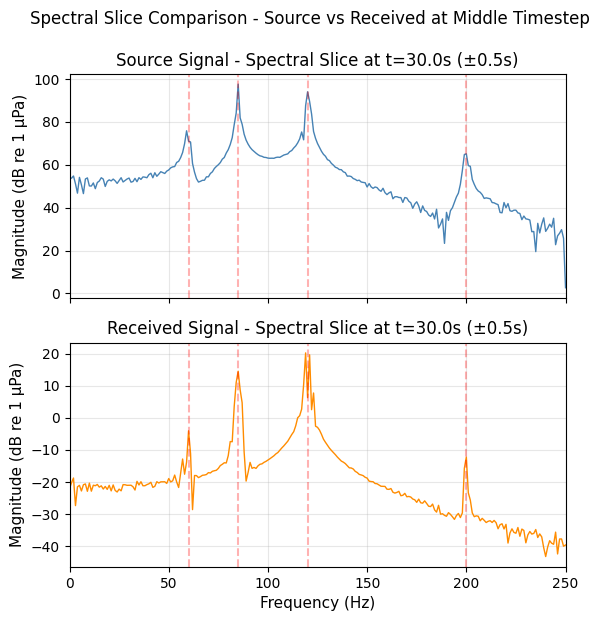

In [68]:
fig5, (ax_slice_source, ax_slice_received) = plt.subplots(2, 1, figsize=(6.4, 6.4), sharex=True)

# Calculate middle timestep
middle_timestep_idx = SIM_PARAMS["num_steps"] // 2
timestep_duration_s = SIM_PARAMS["time_interval"].total_seconds()
middle_time_s = middle_timestep_idx * timestep_duration_s

# Extract 1-second slice around middle time
slice_duration_s = 1.0
slice_half_duration_s = slice_duration_s / 2
slice_start_time_s = middle_time_s - slice_half_duration_s
slice_end_time_s = middle_time_s + slice_half_duration_s

slice_start_sample = int(slice_start_time_s * SIGNAL_PARAMS["sampling_rate_hz"])
slice_end_sample = int(slice_end_time_s * SIGNAL_PARAMS["sampling_rate_hz"])

source_slice = source_signal[slice_start_sample:slice_end_sample]
received_slice = continuous_signal[slice_start_sample:slice_end_sample]

# Compute FFT with correct scaling
source_slice_real = np.real(source_slice)
received_slice_real = np.real(received_slice)

freq_spectrum_source_slice = np.fft.rfft(source_slice_real)
freq_spectrum_received_slice = np.fft.rfft(received_slice_real)

freq_axis_slice = np.fft.rfftfreq(len(source_slice_real), 
                                   1 / SIGNAL_PARAMS["sampling_rate_hz"])

# Correct FFT scaling
N_slice = len(source_slice_real)
spectrum_amplitude_source_slice = np.abs(freq_spectrum_source_slice) * (2.0 / N_slice)
spectrum_amplitude_received_slice = np.abs(freq_spectrum_received_slice) * (2.0 / N_slice)

spectrum_magnitude_db_source_slice = 20 * np.log10(spectrum_amplitude_source_slice + 1e-10)
spectrum_magnitude_db_received_slice = 20 * np.log10(spectrum_amplitude_received_slice + 1e-10)

# Plot source slice
ax_slice_source.plot(freq_axis_slice, spectrum_magnitude_db_source_slice, 
                     linewidth=1.0, color='steelblue')
ax_slice_source.set_ylabel('Magnitude (dB re 1 µPa)', fontsize=11)
ax_slice_source.set_title(f'Source Signal - Spectral Slice at t={middle_time_s:.1f}s (±{slice_half_duration_s}s)')
ax_slice_source.grid(True, alpha=0.3)
ax_slice_source.set_xlim(0, 250)

for freq in TARGET_PARAMS["frequencies_hz"]:
    ax_slice_source.axvline(freq, color="red", linestyle="--", alpha=0.3, linewidth=1.5, label=f'{freq} Hz')

# Plot received slice
ax_slice_received.plot(freq_axis_slice, spectrum_magnitude_db_received_slice, 
                       linewidth=1.0, color='darkorange')
ax_slice_received.set_xlabel('Frequency (Hz)', fontsize=11)
ax_slice_received.set_ylabel('Magnitude (dB re 1 µPa)', fontsize=11)
ax_slice_received.set_title(f'Received Signal - Spectral Slice at t={middle_time_s:.1f}s (±{slice_half_duration_s}s)')
ax_slice_received.grid(True, alpha=0.3)
ax_slice_received.set_xlim(0, 250)

for freq in TARGET_PARAMS["frequencies_hz"]:
    ax_slice_received.axvline(freq, color="red", linestyle="--", alpha=0.3, linewidth=1.5)

plt.suptitle("Spectral Slice Comparison - Source vs Received at Middle Timestep")
plt.show()